In [87]:
from ezio.domain.wizard import load_input_files
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import numpy as np


In [ ]:
from ezio.adapters.gpx import GpxTrackLoader
from tests.test_wizard import MockProgress


files = load_input_files([Path("path/to/data")], [GpxTrackLoader()], MockProgress(), None, None)

In [102]:
def setup_plot_style(figheight: float, figwidth: float = 5.11):
    matplotlib.style.use("fivethirtyeight")
    matplotlib.rc("font", family="sans-serif", size=12)
    matplotlib.rc("figure", figsize=(figwidth, figheight))
    matplotlib.rc("axes", linewidth=1)
    matplotlib.rc("lines", linewidth=2)
    matplotlib.rc("savefig", pad_inches=0.05)
    plt.tick_params(top="off", right="off", which="both")

54.30591474947378
416.6 574.49


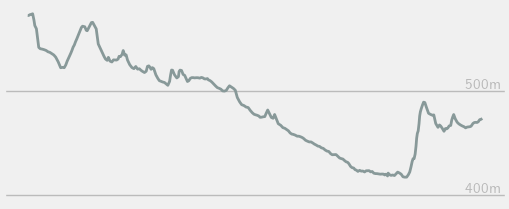

83.76856875165677
219.72 736.93


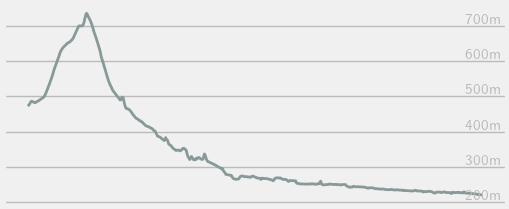

127.71510184089544
129.23 232.72


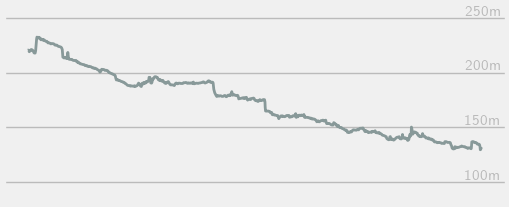

138.90734468728536
94.61 132.25


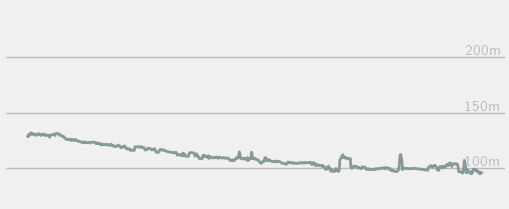

133.67879059642559
71.09 108.93


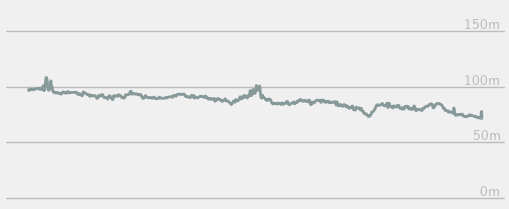

146.2740416334185
43.18 85.6


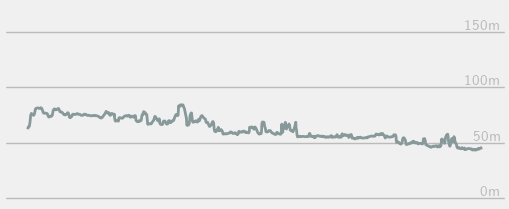

145.0768516227423
17.99 60.78


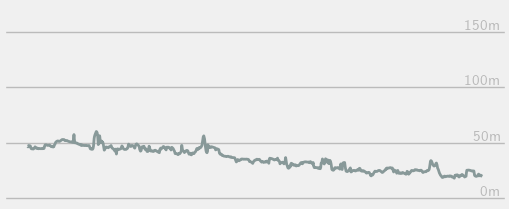

110.96672987634062
6.91 58.03


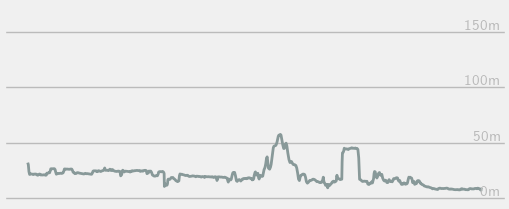

106.94939257530469
-2.71 58.29


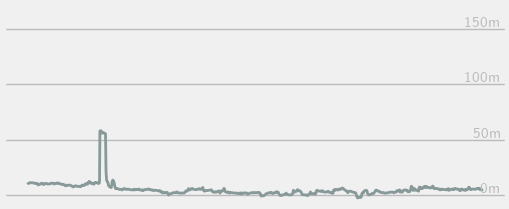

53.29325636895421
3.63 40.28


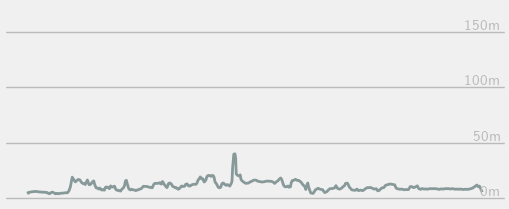

12.62215821657024
3.46 21.66


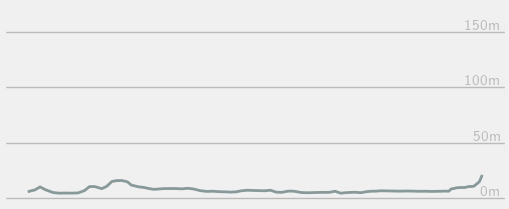

89.84076112684174
4.8 141.59


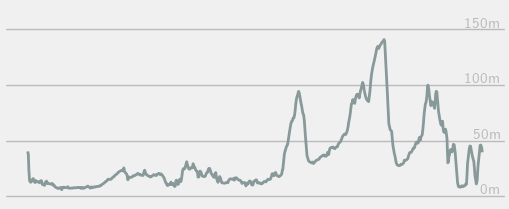

87.3857660667787
3.63 265.04


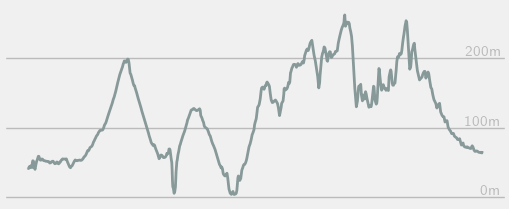

95.51942704037542
30.54 431.95


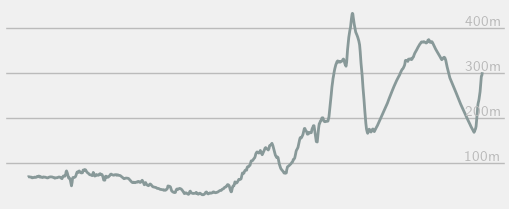

56.639980260493196
114.5 406.16


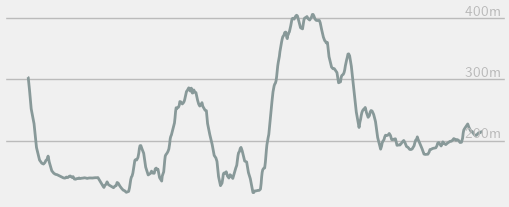

100.7541003611376
5.69 406.35


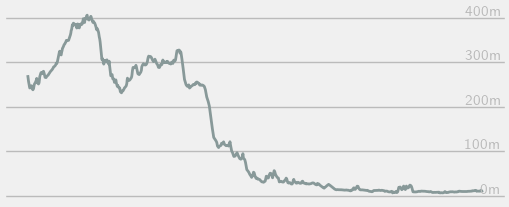

7.186407434398571
209.25 260.75


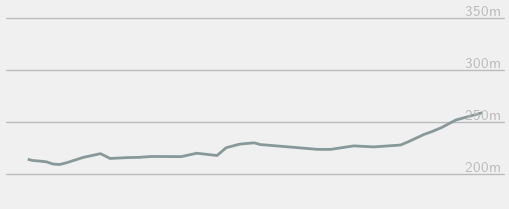

82.05741214139809
2.66 31.91


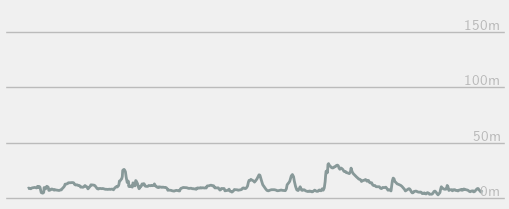

43.89028171504767
5.92 28.19


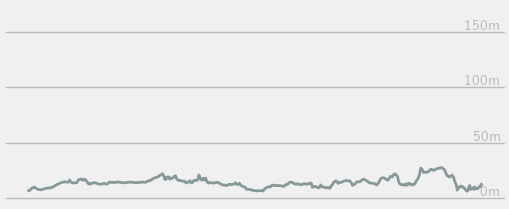

18.376733274327965
6.89 32.05


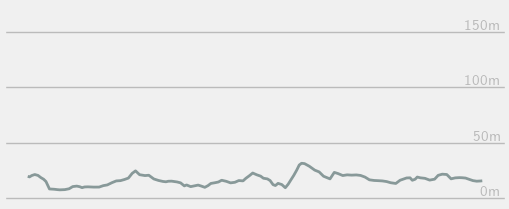

In [114]:
from ezio.domain.geo import (
    earth_surface_distance_km,
    get_elevations,
    smoothed_elevations,
)

for t in files.tracks[:]:
    track = t[1]

    elevations = get_elevations(track)
    distances = []

    coords = track.coordinates

    total_distance: float = 0.0
    for a, b in zip(coords, coords[1:]):
        distances.append(total_distance)
        segment_dist = earth_surface_distance_km(a.lat, a.lon, b.lat, b.lon)
        total_distance += segment_dist

    distances.append(total_distance)
    print(total_distance)

    spacing_y = 100
    minrange_y = 180

    min_y = np.min(elevations)
    max_y = np.max(elevations)
    mid_y = (min_y + max_y) / 2
    lower_line = (mid_y // spacing_y) * spacing_y
    upper_line = lower_line + spacing_y

    lower_unpadded = min(min_y, lower_line)
    upper_unpadded = max(max_y, upper_line)
    range = upper_unpadded - lower_unpadded

    lower = lower_unpadded - range * 0.05
    upper = upper_unpadded + range * 0.05
    range = upper - lower
    if range < minrange_y:
        spacing_y = 50
        remaining = minrange_y - range
        lower = max(lower - remaining / 3, min(lower, 0))
        upper = lower + minrange_y

    print(min_y, max_y)

    setup_plot_style(2, 5)
    plt.ylim(lower, upper)

    plt.yticks(
        np.arange(
            (lower + spacing_y - 1 + spacing_y * 0.05) // spacing_y * spacing_y,
            upper,
            step=spacing_y,
        )
    )
    plt.xticks([])

    ax = plt.gca()

    ax.yaxis.set_tick_params(labelleft=False)

    gridline_col = "#bbb"
    line_col = "#899"

    for tick in ax.yaxis.get_major_ticks():
        y = tick.get_loc()
        ax.text(
            0.99,
            y,
            f"{y:.0f}m",
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="bottom",
            fontsize=11,
            color=gridline_col,
        )
    ax.yaxis.grid(True, color=gridline_col)

    plt.tight_layout(pad=0, w_pad=0, h_pad=0)

    smoothing_size = 6
    plt.plot(
        distances[::smoothing_size],
        smoothed_elevations(elevations, smoothing_size),
        c=line_col,
    )
    plt.show()